# Capítulo 6

---
# Ejercicio 1: ML para multiplicar matrices 2×2



In [ ]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")   # oculta avisos de convergencia
rng = np.random.default_rng(42)   # semilla para reproducibilidad
N = 50_000

## 1.1 Generación del data set

In [ ]:
# A y B: N matrices 2x2 con enteros aleatorios en [-20, 20]
A = rng.integers(-20, 21, size=(N, 2, 2))
B = rng.integers(-20, 21, size=(N, 2, 2))
C = A @ B                                   # resultado analítico (las "etiquetas")

# Features: 8 entradas (A y B aplanadas). Etiquetas: 4 salidas (C aplanada)
X = np.hstack([A.reshape(N, 4), B.reshape(N, 4)]).astype(float)
y = C.reshape(N, 4).astype(float)

cols_X = ["a11","a12","a21","a22","b11","b12","b21","b22"]
cols_y = ["c11","c12","c21","c22"]
df = pd.DataFrame(np.hstack([X, y]), columns=cols_X + cols_y).astype(int)
print("Rango de C:", C.min(), "a", C.max(), "(teórico: -800 a 800)")
df.head()

Rango de C: -780 a 761 (teórico: -800 a 800)


,a11,a12,a21,a22,b11,b12,b21,b22,c11,c12,c21,c22
0,-17,11,6,-3,20,18,19,18,-131,-108,63,54
1,-3,15,-17,8,16,1,8,-10,72,-153,-208,-97
2,-12,-17,1,20,8,10,-3,7,-45,-239,-52,150
3,10,11,9,12,-3,15,-12,14,-162,304,-171,303
4,1,-15,14,-2,11,-9,-14,3,221,-54,182,-132


In [ ]:
# Partición 60 % / 20 % / 20 %  (sección 6.8.1)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.40, random_state=1)
X_va, X_te,  y_va, y_te  = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=1)
print(f"Entrenamiento: {len(X_tr)} | Validación: {len(X_va)} | Prueba: {len(X_te)}")

# Normalización (sección 6.7.4): entradas /20 y salidas /800 -> rango [-1, 1]
SX, SY = 20.0, 800.0

Entrenamiento: 30000 | Validación: 10000 | Prueba: 10000


## 1.2 Modelo 1: regresión lineal sobre las 8 entradas

In [ ]:
t0 = time.perf_counter()
lin = LinearRegression().fit(X_tr / SX, y_tr / SY)
t_lin = time.perf_counter() - t0

pred = lin.predict(X_te / SX) * SY
print(f"Tiempo de entrenamiento: {t_lin:.3f} s")
print(f"MAE en prueba: {mean_absolute_error(y_te, pred):.2f}   R²: {r2_score(y_te, pred):.4f}")

Tiempo de entrenamiento: 0.125 s
MAE en prueba: 155.18   R²: -0.0005


## 1.3 Modelo 2: red neuronal (MLP) sobre las 8 entradas

Tiempo de entrenamiento: 54.5 s  (60 épocas)
Validación -> MAE: 12.41  R²: 0.9935
Prueba     -> MAE: 12.38  R²: 0.9935


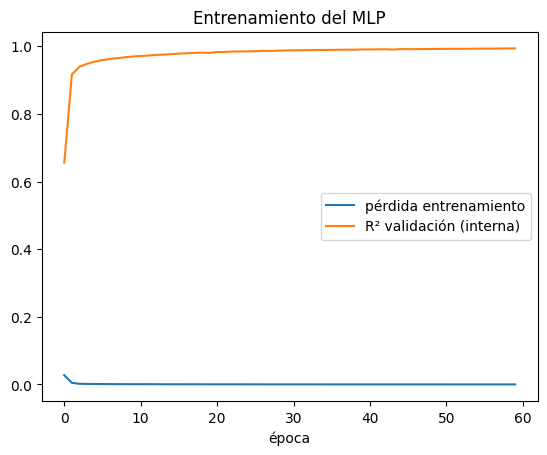

In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation="relu",
                   solver="adam", learning_rate_init=1e-3,
                   max_iter=60, batch_size=256, early_stopping=True,
                   validation_fraction=0.125, n_iter_no_change=8,
                   random_state=0, verbose=False)

t0 = time.perf_counter()
mlp.fit(X_tr / SX, y_tr / SY)
t_mlp = time.perf_counter() - t0

def evaluar(modelo, X_, y_, transformar=lambda z: z):
    p = modelo.predict(transformar(X_ / SX)) * SY
    return mean_absolute_error(y_, p), r2_score(y_, p)

mae_va, r2_va = evaluar(mlp, X_va, y_va)
mae_te, r2_te = evaluar(mlp, X_te, y_te)
print(f"Tiempo de entrenamiento: {t_mlp:.1f} s  ({mlp.n_iter_} épocas)")
print(f"Validación -> MAE: {mae_va:.2f}  R²: {r2_va:.4f}")
print(f"Prueba     -> MAE: {mae_te:.2f}  R²: {r2_te:.4f}")

plt.plot(mlp.loss_curve_, label="pérdida entrenamiento")
plt.plot(mlp.validation_scores_, label="R² validación (interna)")
plt.xlabel("época"); plt.legend(); plt.title("Entrenamiento del MLP"); plt.show()

## 1.4 Modelo 3: regresión lineal con features de segundo orden

In [ ]:
def features_2do_orden(Xn):
    # Productos a_ij * b_kl (16 features). Con ellos, C es una combinación LINEAL de las features.
    a, b = Xn[:, :4], Xn[:, 4:]
    return np.einsum("ni,nj->nij", a, b).reshape(len(Xn), 16)

t0 = time.perf_counter()
lin2 = LinearRegression().fit(features_2do_orden(X_tr / SX), y_tr / SY)
t_lin2 = time.perf_counter() - t0

mae2, r22 = evaluar(lin2, X_te, y_te, features_2do_orden)
print(f"Tiempo de entrenamiento: {t_lin2:.3f} s")
print(f"Prueba -> MAE: {mae2:.6f}  R²: {r22:.6f}")

Tiempo de entrenamiento: 0.028 s
Prueba -> MAE: 0.000000  R²: 1.000000


## 1.5 Comparación con 10 ejemplos: ML vs. operación analítica

In [ ]:
idx = rng.choice(len(X_te), size=10, replace=False)
Xs, ys = X_te[idx], y_te[idx]

p_lin  = lin.predict(Xs / SX) * SY
p_mlp  = mlp.predict(Xs / SX) * SY
p_lin2 = lin2.predict(features_2do_orden(Xs / SX)) * SY

filas = []
for i in range(10):
    a = Xs[i, :4].reshape(2, 2).astype(int)
    b = Xs[i, 4:].reshape(2, 2).astype(int)
    real = a @ b                                    # solución analítica
    filas.append({
        "A": a.tolist(), "B": b.tolist(),
        "C analítica": real.flatten().tolist(),
        "MLP": np.round(p_mlp[i], 1).tolist(),
        "Error máx MLP": round(float(np.abs(p_mlp[i] - real.flatten()).max()), 1),
        "Lineal 2º orden": np.round(p_lin2[i], 1).tolist(),
        "Lineal simple": np.round(p_lin[i], 0).tolist(),
    })
pd.set_option("display.max_colwidth", None, "display.width", 250)
pd.DataFrame(filas)

,A,B,C analítica,MLP,Error máx MLP,Lineal 2º orden,Lineal simple
0,"[[-6, 14], [16, 17]]","[[18, 6], [8, 7]]","[4, 62, 424, 215]","[2.4, 84.1, 424.0, 234.3]",22.1,"[4.0, 62.0, 424.0, 215.0]","[3.0, -1.0, -5.0, -4.0]"
1,"[[-15, -5], [19, -11]]","[[11, -1], [10, -4]]","[-215, 35, 99, 25]","[-232.6, 62.8, 116.6, 14.2]",27.8,"[-215.0, 35.0, 99.0, 25.0]","[4.0, 4.0, 2.0, -1.0]"
2,"[[-5, -15], [-20, 6]]","[[0, 18], [6, -12]]","[-90, 90, 36, -432]","[-94.8, 64.1, 53.0, -399.4]",32.6,"[-90.0, 90.0, 36.0, -432.0]","[1.0, -3.0, -1.0, -4.0]"
3,"[[-2, 3], [8, -13]]","[[8, 4], [15, -19]]","[29, -65, -131, 279]","[38.2, -84.2, -125.6, 269.8]",19.2,"[29.0, -65.0, -131.0, 279.0]","[0.0, 4.0, 4.0, -1.0]"
4,"[[16, 3], [-17, -2]]","[[-7, -16], [14, 20]]","[-70, -196, 91, 232]","[-71.3, -192.1, 99.5, 208.0]",24.0,"[-70.0, -196.0, 91.0, 232.0]","[2.0, -0.0, -1.0, 5.0]"
5,"[[-16, 10], [2, 19]]","[[18, -3], [18, -5]]","[-108, -2, 378, -101]","[-106.4, 14.0, 363.7, -92.2]",16.0,"[-108.0, -2.0, 378.0, -101.0]","[4.0, -1.0, -2.0, -6.0]"
6,"[[17, 15], [-12, -13]]","[[3, -10], [19, -2]]","[336, -200, -283, 146]","[326.7, -220.6, -289.9, 157.2]",20.6,"[336.0, -200.0, -283.0, 146.0]","[-1.0, 3.0, 2.0, 4.0]"
7,"[[-20, -3], [-15, 15]]","[[7, 11], [1, -12]]","[-143, -184, -90, -345]","[-159.3, -184.3, -92.2, -360.1]",16.3,"[-143.0, -184.0, -90.0, -345.0]","[3.0, -3.0, -2.0, -5.0]"
8,"[[-18, 2], [7, 15]]","[[-17, 6], [-14, -2]]","[278, -112, -329, 12]","[276.3, -107.5, -330.1, 21.6]",9.6,"[278.0, -112.0, -329.0, 12.0]","[3.0, -1.0, 1.0, -2.0]"
9,"[[9, 17], [12, -8]]","[[-15, 12], [5, -15]]","[-50, -147, -220, 264]","[-56.9, -157.0, -230.9, 277.7]",13.7,"[-50.0, -147.0, -220.0, 264.0]","[-4.0, 4.0, 5.0, -0.0]"


## 1.6 ¿Qué es más costoso computacionalmente?

Comparamos (a) el **tiempo de ejecución** y (b) el **número de operaciones** de la solución analítica y del modelo ya entrenado.
Para la solución analítica medimos dos versiones: un ciclo de Python puro y NumPy vectorizado.

In [ ]:
def matmul_python(Xs_):
    # Solución analítica con ciclos de Python puro: 8 multiplicaciones + 4 sumas por matriz
    out = []
    for r in Xs_:
        a11,a12,a21,a22,b11,b12,b21,b22 = r
        out.append((a11*b11 + a12*b21, a11*b12 + a12*b22,
                    a21*b11 + a22*b21, a21*b12 + a22*b22))
    return out

def medir(f, repeticiones):
    t0 = time.perf_counter()
    for _ in range(repeticiones):
        f()
    return (time.perf_counter() - t0) / repeticiones

resultados = []
for nombre, n in [("10 ejemplos", 10), ("50.000 ejemplos", 50_000)]:
    sub = X_te[:n] if n <= len(X_te) else np.vstack([X_te] * (n // len(X_te) + 1))[:n]
    subl = sub.tolist()
    rep = 2000 if n == 10 else 3
    t_py  = medir(lambda: matmul_python(subl), rep)
    t_np  = medir(lambda: sub[:, :4].reshape(-1,2,2) @ sub[:, 4:].reshape(-1,2,2), rep)
    t_ml  = medir(lambda: mlp.predict(sub / SX), rep)
    resultados.append({"Caso": nombre,
                       "Analítica (Python) [ms]": t_py*1e3,
                       "Analítica (NumPy) [ms]": t_np*1e3,
                       "MLP predicción [ms]": t_ml*1e3})
res = pd.DataFrame(resultados).set_index("Caso")
res.round(4)

,Analítica (Python) [ms],Analítica (NumPy) [ms],MLP predicción [ms]
Caso,,,
10 ejemplos,0.0034,0.0060,0.1642
50.000 ejemplos,25.8184,9.1651,68.1784


In [ ]:
# Conteo de operaciones por multiplicación de matrices
ops_analitica = 8 + 4                                   # 8 multiplicaciones + 4 sumas
capas = [8] + list(mlp.hidden_layer_sizes) + [4]
mults_mlp = sum(capas[i] * capas[i+1] for i in range(len(capas)-1))   # multiplicaciones de pesos
ops_mlp = 2 * mults_mlp                                 # ~ una mult. + una suma por peso
n_parametros = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)

print(f"Analítica : {ops_analitica} operaciones por multiplicación")
print(f"MLP (8-64-64-4): {n_parametros} parámetros, ~{ops_mlp} operaciones por predicción")
print(f"-> el MLP necesita ~{ops_mlp/ops_analitica:.0f} veces más operaciones que la fórmula exacta\n")

print(f"Costo ÚNICO de entrenamiento: MLP = {t_mlp:.1f} s | regresión lineal 2º orden = {t_lin2:.3f} s | "
      f"solución analítica = 0 s (no entrena)")

Analítica : 12 operaciones por multiplicación
MLP (8-64-64-4): 4996 parámetros, ~9728 operaciones por predicción
-> el MLP necesita ~811 veces más operaciones que la fórmula exacta

Costo ÚNICO de entrenamiento: MLP = 54.5 s | regresión lineal 2º orden = 0.028 s | solución analítica = 0 s (no entrena)


---
# Ejercicio 5: Bayes ingenuo  – filtro de spam



## 5.2 Data set (rotulado)

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

spam = [
    "gana dinero gratis ahora haz clic aquí",
    "regalo gratis tarjeta de crédito aprobada",
    "oferta exclusiva compra ahora descuento gratis",
    "has ganado un premio reclama tu regalo ahora",
    "dinero fácil sin esfuerzo gana ahora",
    "tarjeta de crédito sin costo solicita ya",
    "felicidades ganaste un viaje gratis haz clic",
    "oferta limitada compra barato ahora",
    "préstamo inmediato dinero rápido sin papeles",
    "haz clic y reclama tu premio gratis",
    "descuento exclusivo regalo para ti compra ya",
    "ayuda urgente transfiere dinero y gana un premio",
]
ham = [
    "reunión del proyecto mañana a las nueve",
    "adjunto el informe de la clase de machine learning",
    "podemos revisar el código del laboratorio hoy",
    "te envío las notas de la reunión de ayer",
    "recordatorio entrega del taller de redes neuronales",
    "gracias por la ayuda con el ejercicio de la tarea",
    "nos vemos en la biblioteca para estudiar el examen",
    "adjunto la presentación para la reunión del lunes",
    "por favor revisa el dataset que subí al repositorio",
    "mañana tenemos clase de inteligencia artificial",
    "te comparto el notebook con los resultados del modelo",
    "buenos días envío la tarea de la semana",
]
textos = spam + ham
rotulos = ["spam"] * len(spam) + ["ham"] * len(ham)
df = pd.DataFrame({"texto": textos, "clase": rotulos})
print(df["clase"].value_counts())
df.sample(5, random_state=0)

clase
spam    12
ham     12
Name: count, dtype: int64


,texto,clase
11,ayuda urgente transfiere dinero y gana un premio,spam
10,descuento exclusivo regalo para ti compra ya,spam
22,te comparto el notebook con los resultados del modelo,ham
14,podemos revisar el código del laboratorio hoy,ham
20,por favor revisa el dataset que subí al repositorio,ham


## 5.3 Implementación desde cero (para entender el algoritmo)

In [ ]:
def tokenizar(texto):
    return re.findall(r"[a-záéíóúñü]+", texto.lower())

class NaiveBayesDesdeCero:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, textos, clases):
        self.clases = sorted(set(clases))
        n = len(clases)
        # 1) Probabilidad a priori P(c)
        self.log_prior = {c: np.log(clases.count(c) / n) for c in self.clases}
        # 2) Conteo de palabras por clase
        self.conteos = {c: Counter() for c in self.clases}
        for t, c in zip(textos, clases):
            self.conteos[c].update(tokenizar(t))
        self.vocab = set().union(*[set(cn) for cn in self.conteos.values()])
        self.total = {c: sum(self.conteos[c].values()) for c in self.clases}
        return self

    def log_verosimilitud(self, palabra, c):
        # P(w|c) con suavizado de Laplace
        num = self.conteos[c][palabra] + self.alpha
        den = self.total[c] + self.alpha * len(self.vocab)
        return np.log(num / den)

    def puntajes(self, texto):
        # log P(c) + sum log P(w|c), ignorando palabras fuera del vocabulario
        palabras = [w for w in tokenizar(texto) if w in self.vocab]
        return {c: self.log_prior[c] + sum(self.log_verosimilitud(w, c) for w in palabras)
                for c in self.clases}

    def predict_proba(self, texto):
        s = self.puntajes(texto)
        m = max(s.values())
        exp = {c: np.exp(v - m) for c, v in s.items()}        # normalización estable
        z = sum(exp.values())
        return {c: v / z for c, v in exp.items()}

    def predict(self, textos):
        resultado = []
        for t in textos:
            p = self.puntajes(t)
            resultado.append(max(p, key=p.get))
        return resultado

In [ ]:
# Partición entrenamiento/prueba (estratificada para mantener la proporción spam/ham)
t_tr, t_te, c_tr, c_te = train_test_split(textos, rotulos, test_size=0.25,
                                          random_state=3, stratify=rotulos)
print(f"Entrenamiento: {len(t_tr)} | Prueba: {len(t_te)}")

nb = NaiveBayesDesdeCero(alpha=1.0).fit(t_tr, c_tr)
print("Tamaño del vocabulario |V| =", len(nb.vocab))
print("Prior:", {c: round(float(np.exp(v)), 3) for c, v in nb.log_prior.items()})

Entrenamiento: 18 | Prueba: 6
Tamaño del vocabulario |V| = 81
Prior: {'ham': 0.5, 'spam': 0.5}


## 5.4 Ejemplo calculado paso a paso

In [ ]:
nuevo = "gana un premio gratis ahora"
print("Correo:", nuevo, "\n")
palabras = [w for w in tokenizar(nuevo) if w in nb.vocab]
print("Palabras conocidas:", palabras, "\n")

for c in nb.clases:
    print(f"--- Clase {c} ---")
    print(f"log P({c}) = {nb.log_prior[c]:.3f}")
    total = nb.log_prior[c]
    for w in palabras:
        lv = nb.log_verosimilitud(w, c)
        total += lv
        print(f"  log P({w}|{c}) = {lv:.3f}")
    print(f"  Puntaje total = {total:.3f}\n")

proba = nb.predict_proba(nuevo)
print("Probabilidades posteriores:", {c: round(float(p), 4) for c, p in proba.items()})
print("Predicción:", max(proba, key=proba.get))

Correo: gana un premio gratis ahora 

Palabras conocidas: ['gana', 'un', 'premio', 'gratis', 'ahora'] 

--- Clase ham ---
log P(ham) = -0.693
  log P(gana|ham) = -5.043
  log P(un|ham) = -5.043
  log P(premio|ham) = -5.043
  log P(gratis|ham) = -5.043
  log P(ahora|ham) = -5.043
  Puntaje total = -25.910

--- Clase spam ---
log P(spam) = -0.693
  log P(gana|spam) = -3.570
  log P(un|spam) = -3.570
  log P(premio|spam) = -3.570
  log P(gratis|spam) = -3.164
  log P(ahora|spam) = -3.346
  Puntaje total = -17.912

Probabilidades posteriores: {'ham': 0.0003, 'spam': 0.9997}
Predicción: spam


La clase con el mayor puntaje (log-probabilidad posterior sin normalizar) es la predicción.
Palabras como *gratis*, *premio* y *ahora* son mucho más frecuentes en spam, por lo que inclinan la decisión hacia esa clase.

## 5.5 Evaluación: matriz de confusión y métricas

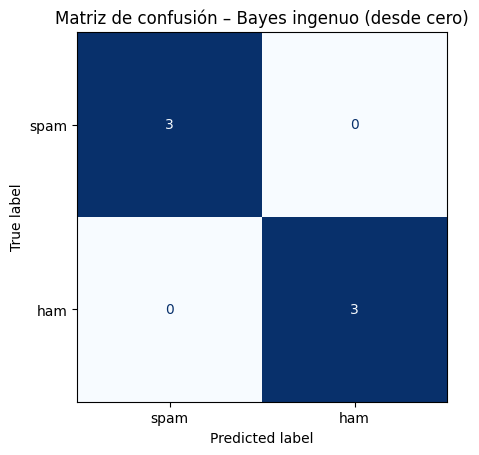

Exactitud (accuracy): 1.0
Precisión (spam):     1.0
Exhaustividad (recall, spam): 1.0


In [ ]:
pred = nb.predict(t_te)
etiquetas = ["spam", "ham"]
cm = confusion_matrix(c_te, pred, labels=etiquetas)
ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusión – Bayes ingenuo (desde cero)"); plt.show()

print("Exactitud (accuracy):", accuracy_score(c_te, pred))
print("Precisión (spam):    ", precision_score(c_te, pred, pos_label="spam", zero_division=0))
print("Exhaustividad (recall, spam):", recall_score(c_te, pred, pos_label="spam", zero_division=0))

**Nota:** con un data set tan pequeño las métricas son muy variables; sirven para ilustrar el método.
En un caso real se usan miles de correos (por ejemplo el data set *SMS Spam Collection* o *Enron*).
En spam suele importar más evitar los **falsos positivos** (un correo bueno marcado como spam) que los falsos negativos.

## 5.6 Validación con scikit-learn

In [ ]:
vec = CountVectorizer(token_pattern=r"[a-záéíóúñü]+")
Xtr = vec.fit_transform(t_tr)
Xte = vec.transform(t_te)

sk = MultinomialNB(alpha=1.0).fit(Xtr, c_tr)
pred_sk = sk.predict(Xte)

print("Exactitud sklearn      :", accuracy_score(c_te, pred_sk))
print("Exactitud desde cero   :", accuracy_score(c_te, pred))
print("¿Mismas predicciones?  :", list(pred_sk) == list(pred))

# Las palabras más "spam": mayor log P(w|spam) - log P(w|ham)
i_spam = list(sk.classes_).index("spam"); i_ham = list(sk.classes_).index("ham")
dif = sk.feature_log_prob_[i_spam] - sk.feature_log_prob_[i_ham]
orden = np.argsort(dif)
palabras = np.array(vec.get_feature_names_out())
print("\nTop 8 palabras indicadoras de SPAM:", list(palabras[orden[-8:]][::-1]))
print("Top 8 palabras indicadoras de HAM :", list(palabras[orden[:8]]))

Exactitud sklearn      : 1.0
Exactitud desde cero   : 1.0
¿Mismas predicciones?  : True

Top 8 palabras indicadoras de SPAM: ['gratis', 'dinero', 'ahora', 'premio', 'gana', 'clic', 'haz', 'un']
Top 8 palabras indicadoras de HAM : ['la', 'el', 'del', 'reunión', 'de', 'envío', 'las', 'para']


## 5.7 El filtro se adapta con nuevos datos (sección 6.4)

In [ ]:
# Aparece una nueva campaña de spam con palabras nuevas ("pandemia", "anticovid")
nuevos_spam = ["compra anticovid gratis pandemia oferta",
               "pandemia gana dinero con anticovid ahora",
               "ayuda pandemia soledad regalo gratis haz clic"]
prueba = "oferta anticovid pandemia gratis"

antes = NaiveBayesDesdeCero().fit(t_tr, c_tr)
despues = NaiveBayesDesdeCero().fit(t_tr + nuevos_spam, c_tr + ["spam"] * 3)

print("Antes     :", {c: round(float(p), 3) for c, p in antes.predict_proba(prueba).items()})
print("Después   :", {c: round(float(p), 3) for c, p in despues.predict_proba(prueba).items()})

Antes     : {'ham': 0.065, 'spam': 0.935}
Después   : {'ham': 0.003, 'spam': 0.997}
